Please upload creditcard.csv


Saving creditcard.csv to creditcard.csv
Dataset loaded successfully!
Shape: (284807, 31)

Dataset after cleaning: (100000, 31)

Class Count:
Class
0    99839
1      161
Name: count, dtype: int64


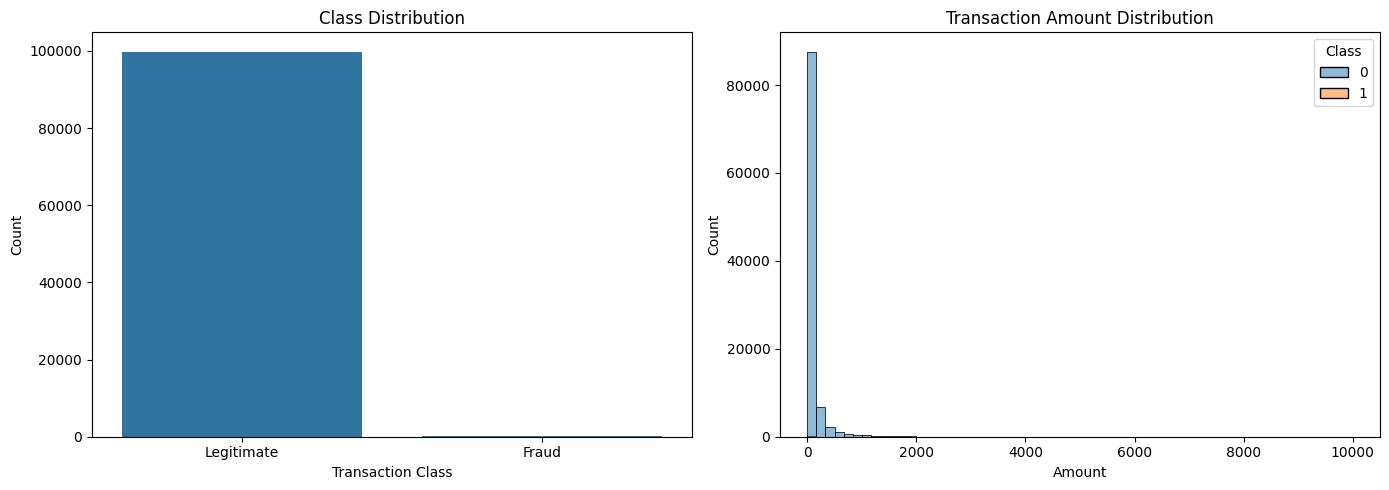


Before SMOTE:
Class
0    79871
1      129
Name: count, dtype: int64

After SMOTE:
Class
0    79871
1    79871
Name: count, dtype: int64

Training Logistic Regression...
Logistic Regression completed in 2.59 seconds

Training Naive Bayes...
Naive Bayes completed in 0.09 seconds

Training SVM...
SVM completed in 2.13 seconds

Training Decision Tree...
Decision Tree completed in 10.31 seconds

Training Random Forest...
Random Forest completed in 38.93 seconds

Training XGBoost...
XGBoost completed in 2.35 seconds

Training Fast Stacking Ensemble...
Fast Stacking Ensemble completed in 42.15 seconds

Logistic Regression
              precision    recall  f1-score   support

       Legit       1.00      0.97      0.98     19968
       Fraud       0.05      0.94      0.09        32

    accuracy                           0.97     20000
   macro avg       0.52      0.95      0.54     20000
weighted avg       1.00      0.97      0.98     20000



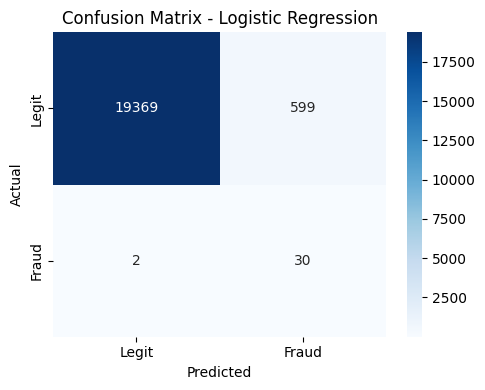


Naive Bayes
              precision    recall  f1-score   support

       Legit       1.00      0.98      0.99     19968
       Fraud       0.06      0.94      0.11        32

    accuracy                           0.98     20000
   macro avg       0.53      0.96      0.55     20000
weighted avg       1.00      0.98      0.99     20000



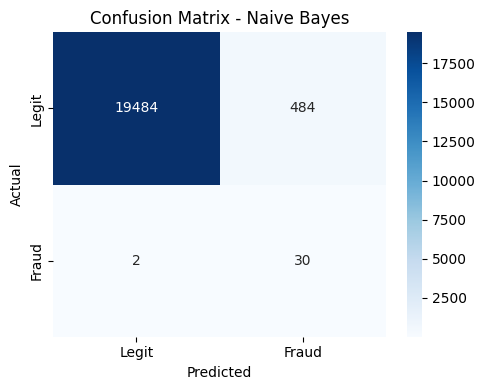


SVM
              precision    recall  f1-score   support

       Legit       1.00      0.97      0.98     19968
       Fraud       0.05      0.94      0.09        32

    accuracy                           0.97     20000
   macro avg       0.52      0.95      0.54     20000
weighted avg       1.00      0.97      0.98     20000



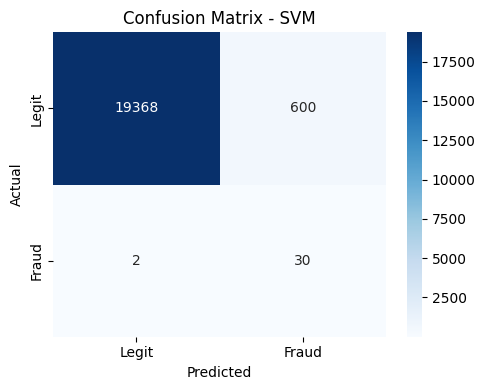


Decision Tree
              precision    recall  f1-score   support

       Legit       1.00      0.98      0.99     19968
       Fraud       0.08      0.91      0.15        32

    accuracy                           0.98     20000
   macro avg       0.54      0.94      0.57     20000
weighted avg       1.00      0.98      0.99     20000



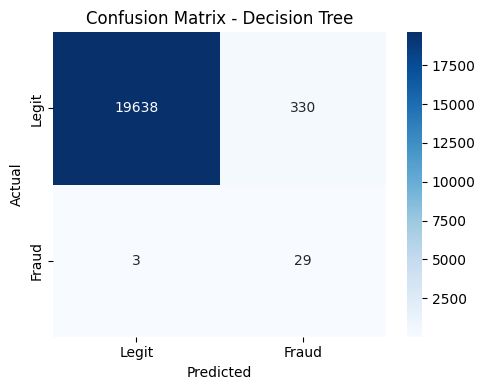


Random Forest
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     19968
       Fraud       0.56      0.91      0.69        32

    accuracy                           1.00     20000
   macro avg       0.78      0.95      0.84     20000
weighted avg       1.00      1.00      1.00     20000



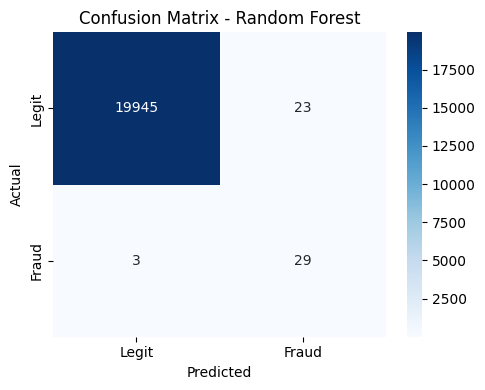


XGBoost
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     19968
       Fraud       0.25      0.94      0.39        32

    accuracy                           1.00     20000
   macro avg       0.62      0.97      0.69     20000
weighted avg       1.00      1.00      1.00     20000



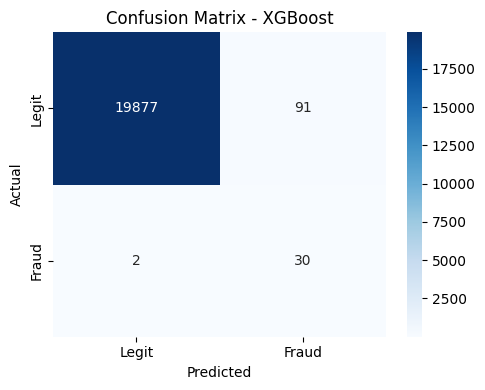


Stacking Ensemble
              precision    recall  f1-score   support

       Legit       1.00      0.99      1.00     19968
       Fraud       0.16      0.94      0.27        32

    accuracy                           0.99     20000
   macro avg       0.58      0.96      0.63     20000
weighted avg       1.00      0.99      0.99     20000



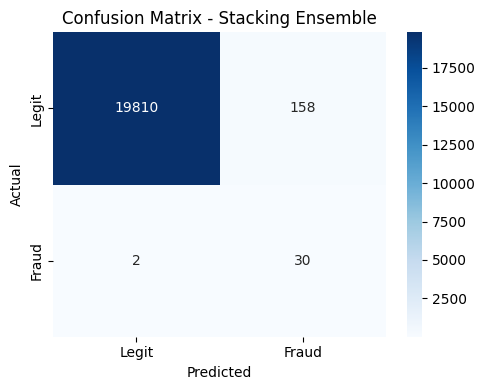


Final Results Table
                 Model  Precision   Recall        F1   ROC-AUC    PR-AUC
0  Logistic Regression   0.047695  0.93750  0.090772  0.989887  0.766902
1          Naive Bayes   0.058366  0.93750  0.109890  0.987873  0.097567
2                  SVM   0.047619  0.93750  0.090634  0.993706  0.730797
3        Decision Tree   0.080780  0.90625  0.148338  0.924300  0.500812
4        Random Forest   0.557692  0.90625  0.690476  0.998687  0.853065
5              XGBoost   0.247934  0.93750  0.392157  0.995588  0.869838
6    Stacking Ensemble   0.159574  0.93750  0.272727  0.990407  0.710537


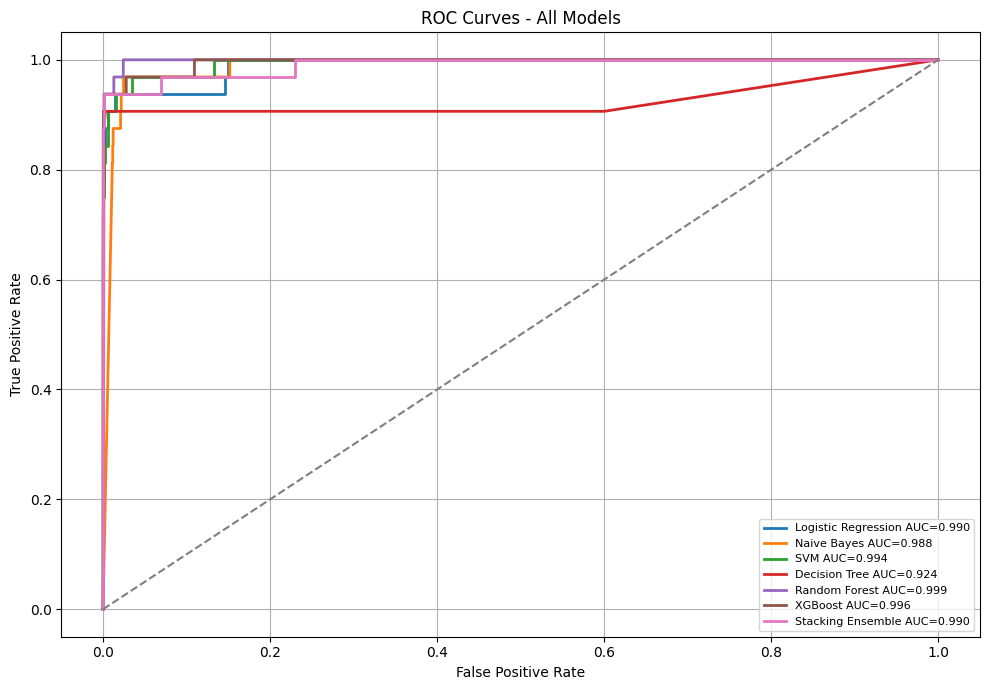

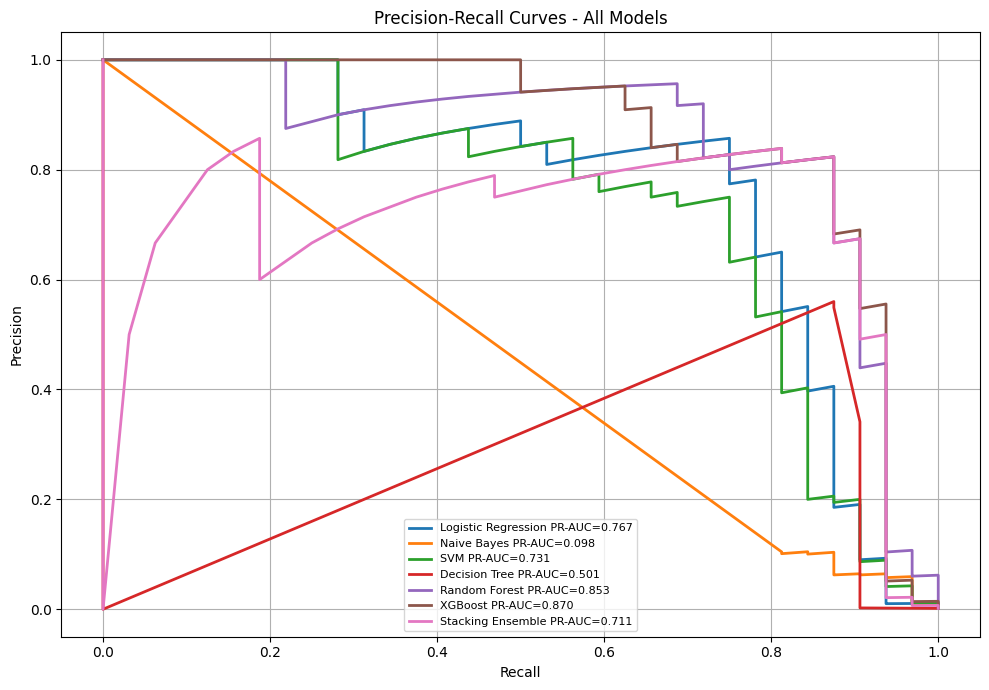

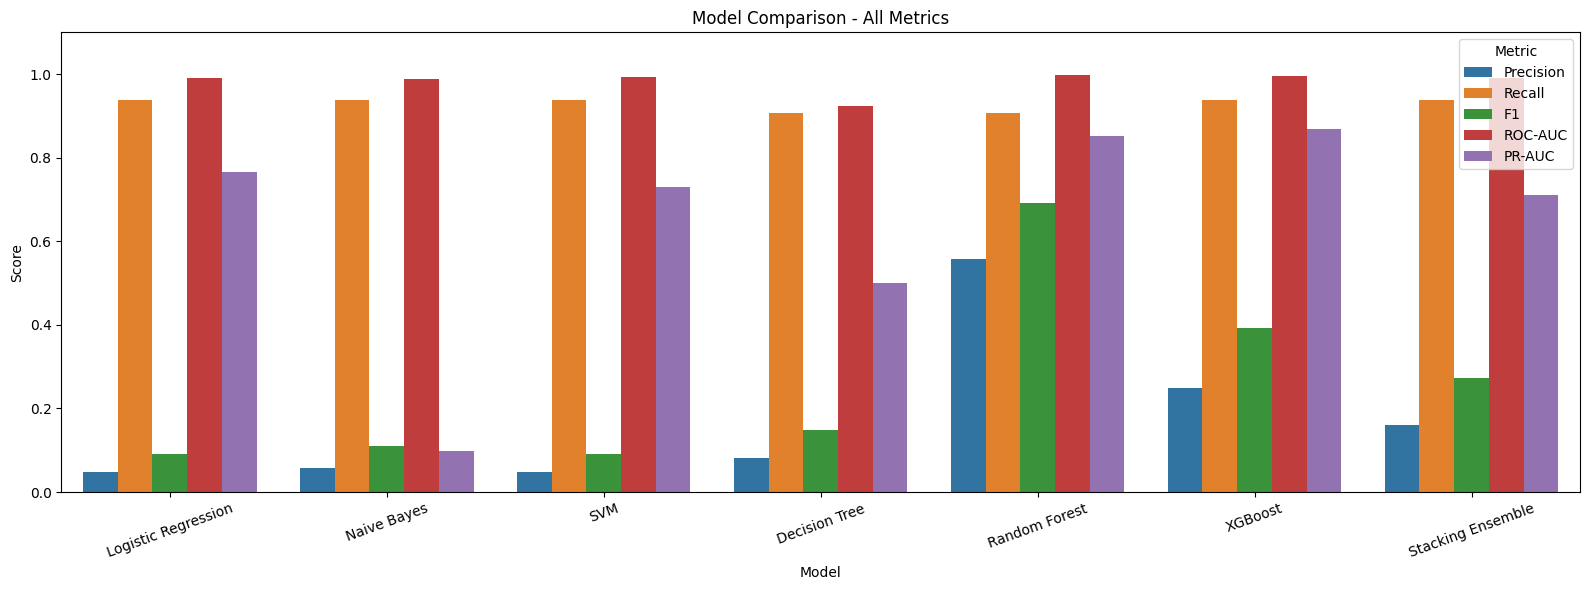

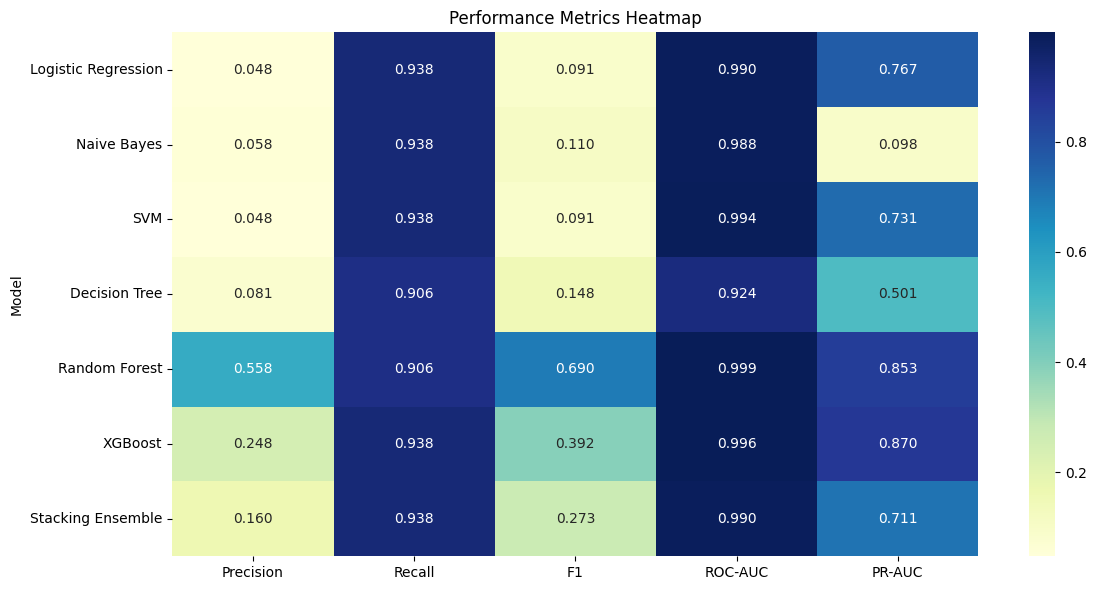

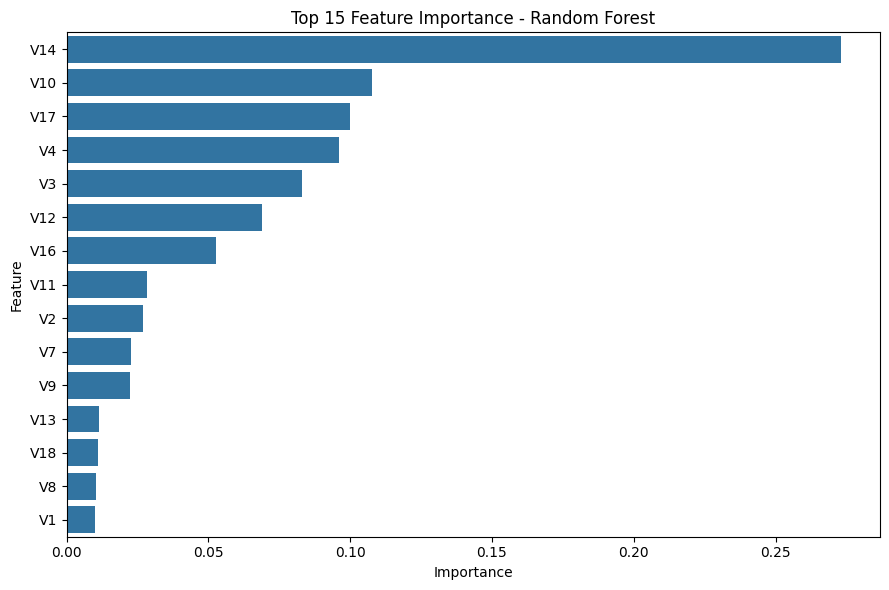

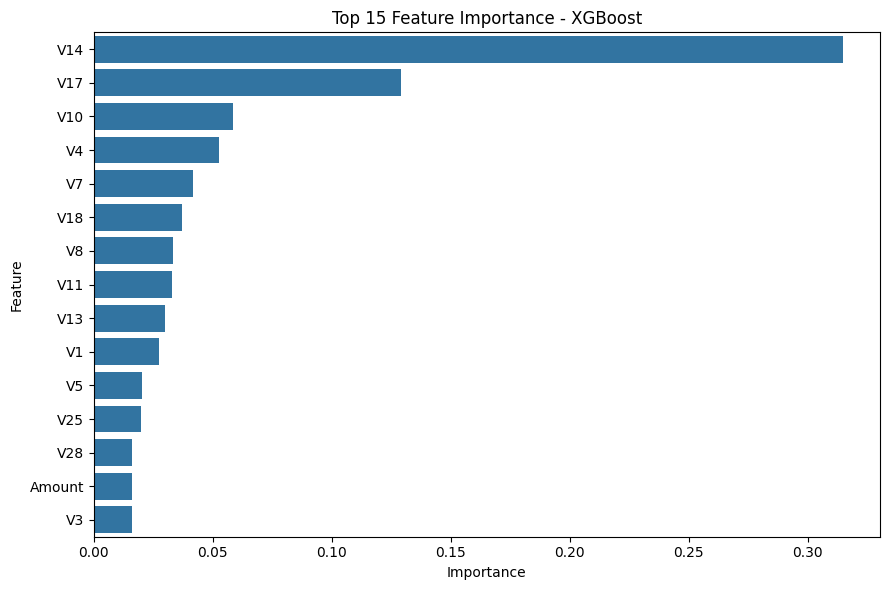


Computing SHAP values...


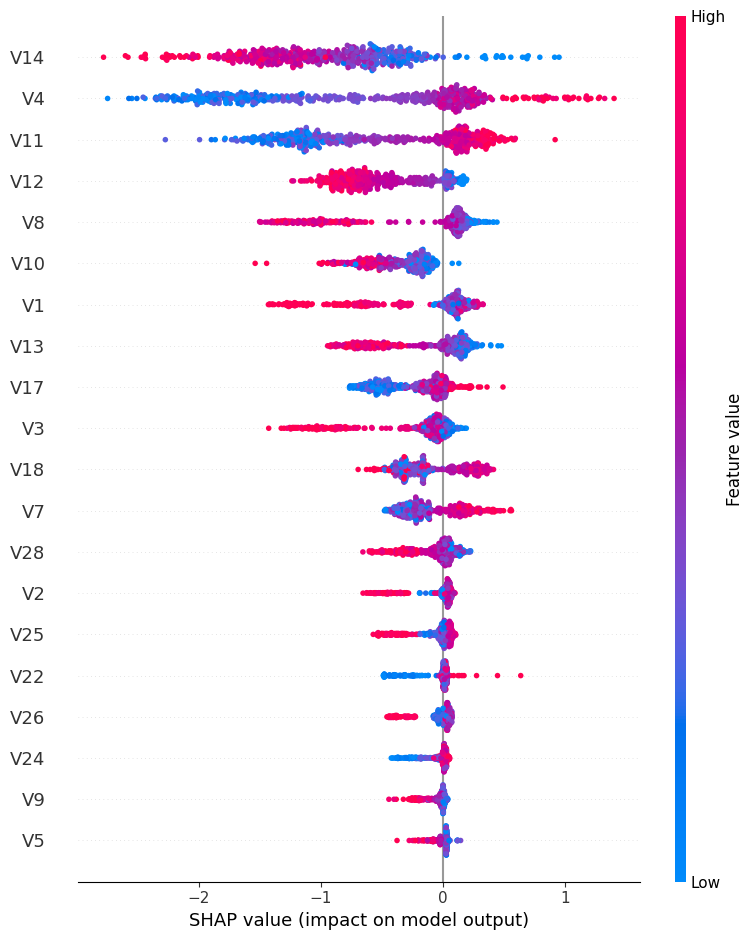

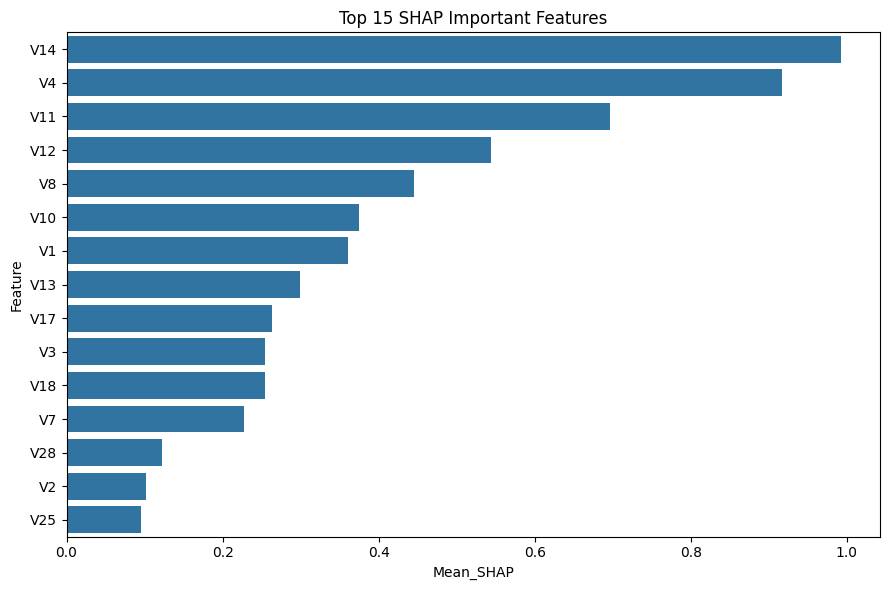


Top 10 SHAP Features
   Feature  Mean_SHAP
14     V14   0.992818
4       V4   0.917213
11     V11   0.695943
12     V12   0.543705
8       V8   0.445190
10     V10   0.374327
1       V1   0.360569
13     V13   0.299588
17     V17   0.263288
3       V3   0.254918


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done!
Downloaded file contains:
1. All graphs
2. Saved models
3. results.csv
4. shap_values.csv


In [ ]:

# Financial  transaction fraud Detction
import warnings
warnings.filterwarnings("ignore")

import os
import time
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    classification_report
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

import joblib
import shap

# Creating output folders to make sure that all the results are together and we can download the outputs as zip file

os.makedirs("outputs/plots", exist_ok=True)
os.makedirs("outputs/models", exist_ok=True)


# STEP 1: UPLOADING DATASET
# Upload the creditcard.csv file from local system and load it into a pandas dataframe.

print("Please upload creditcard.csv")
uploaded = files.upload()

df = pd.read_csv("creditcard.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
# STEP 2: DATA CLEANING:Remove rows with missing target values, fix data types,
# and use sample rows if dataset is too large.

df = df.dropna(subset=["Class"])
df["Class"] = df["Class"].astype(int)

# Fast mode: use 100k rows
if len(df) > 100000:
    df = df.sample(n=100000, random_state=42)

print("\nDataset after cleaning:", df.shape)
print("\nClass Count:")
print(df["Class"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="Class", ax=axes[0])
axes[0].set_title("Class Distribution")
axes[0].set_xticklabels(["Legitimate", "Fraud"])
axes[0].set_xlabel("Transaction Class")
axes[0].set_ylabel("Count")

sns.histplot(data=df, x="Amount", hue="Class", bins=60, ax=axes[1])
axes[1].set_title("Transaction Amount Distribution")
axes[1].set_xlabel("Amount")

plt.tight_layout()
plt.savefig("outputs/plots/eda.png", dpi=150)
plt.show()

# STEP 3: APPLY SMOTE FOR CLASS BALANCING
# Use SMOTE to generate synthetic fraud samples and balance both classes in training data.

scaler = MinMaxScaler()

df["Amount"] = scaler.fit_transform(df[["Amount"]])
df["Time"] = scaler.fit_transform(df[["Time"]])

X = df.drop("Class", axis=1)
y = df["Class"]

FEATURE_NAMES = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("\nBefore SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train).value_counts())

# STEP 4: DEFINE MACHINE LEARNING MODELS
# Create Logistic Regression, Naive Bayes, SVM,Decision Tree, Random Forest, and XGBoost models.

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ),

    "Naive Bayes": GaussianNB(),

    "SVM": CalibratedClassifierCV(
        LinearSVC(
            class_weight="balanced",
            random_state=42,
            max_iter=3000
        ),
        cv=2
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=50,
        max_depth=8,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=80,
        max_depth=4,
        learning_rate=0.08,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        n_jobs=-1,
        random_state=42
    )
}

# STEP 5: TRAIN ALL MODELS
# Train each machine learning model one by one, record training time, and save trained models.

trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    start = time.time()

    model.fit(X_train, y_train)

    end = time.time()
    print(f"{name} completed in {end - start:.2f} seconds")

    trained_models[name] = model

    joblib.dump(
        model,
        f"outputs/models/{name.replace(' ', '_').lower()}.pkl"
    )

#STEP 8: TRAIN STACKING ENSEMBLE MODEL
# Combine multiple base models into one final model to improve prediction performance.

stacking_model = StackingClassifier(
    estimators=[
        ("lr", LogisticRegression(
            max_iter=500,
            class_weight="balanced",
            n_jobs=-1,
            random_state=42
        )),

        ("rf", RandomForestClassifier(
            n_estimators=30,
            max_depth=6,
            n_jobs=-1,
            random_state=42
        )),

        ("xgb", XGBClassifier(
            n_estimators=50,
            max_depth=3,
            learning_rate=0.1,
            eval_metric="logloss",
            n_jobs=-1,
            random_state=42
        ))
    ],

    final_estimator=LogisticRegression(
        max_iter=500,
        random_state=42
    ),

    cv=2,
    stack_method="predict_proba",
    n_jobs=-1
)

print("\nTraining Fast Stacking Ensemble...")
start = time.time()

stacking_model.fit(X_train, y_train)

end = time.time()
print(f"Fast Stacking Ensemble completed in {end - start:.2f} seconds")

trained_models["Stacking Ensemble"] = stacking_model

joblib.dump(
    stacking_model,
    "outputs/models/stacking_ensemble.pkl"
)

# STEP 6: EVALUATE ALL MODELS
# Predict test data and calculate Precision, Recall,F1-score, ROC-AUC, PR-AUC, and confusion matrices.

results = []

for name, model in trained_models.items():

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "_pred": y_pred,
        "_prob": y_prob
    })

    print(classification_report(
        y_test,
        y_pred,
        target_names=["Legit", "Fraud"]
    ))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Legit", "Fraud"],
        yticklabels=["Legit", "Fraud"]
    )
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(f"outputs/plots/cm_{name.replace(' ', '_').lower()}.png", dpi=150)
    plt.show()
# STEP 9: FINAL RESULTS TABLE


df_res = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith("_")}
    for r in results
])

print("\nFinal Results Table")
print(df_res)

df_res.to_csv("outputs/results.csv", index=False)

# STEP 7: ROC CURVE COMPARISON
# Plot ROC curves of all models to compare classification performance visually

plt.figure(figsize=(10, 7))

for r in results:
    fpr, tpr, _ = roc_curve(y_test, r["_prob"])
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{r['Model']} AUC={r['ROC-AUC']:.3f}"
    )

plt.plot([0, 1], [0, 1], "--")
plt.title("ROC Curves - All Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.savefig("outputs/plots/roc_curves.png", dpi=150)
plt.show()

# STEP 8: PRECISION RECALL CURVE
# Plot Precision-Recall curves to measure fraud detection quality on imbalanced data.

plt.figure(figsize=(10, 7))

for r in results:
    precision_curve, recall_curve, _ = precision_recall_curve(
        y_test,
        r["_prob"]
    )
    plt.plot(
        recall_curve,
        precision_curve,
        linewidth=2,
        label=f"{r['Model']} PR-AUC={r['PR-AUC']:.3f}"
    )

plt.title("Precision-Recall Curves - All Models")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.savefig("outputs/plots/pr_curves.png", dpi=150)
plt.show()

# STEP 9: MODEL COMPARISON GRAPH
# Create grouped bar chart to compare all metrics across all models.

metrics = ["Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]

df_melted = df_res.melt(
    id_vars="Model",
    value_vars=metrics,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(16, 6))
sns.barplot(
    data=df_melted,
    x="Model",
    y="Score",
    hue="Metric"
)
plt.title("Model Comparison - All Metrics")
plt.ylim(0, 1.1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("outputs/plots/model_comparison.png", dpi=150)
plt.show()

# STEP 10: PERFORMANCE HEATMAP
# Display all model scores in heatmap form for quick comparison and interpretation.

plt.figure(figsize=(12, 6))
sns.heatmap(
    df_res.set_index("Model"),
    annot=True,
    cmap="YlGnBu",
    fmt=".3f"
)
plt.title("Performance Metrics Heatmap")
plt.tight_layout()
plt.savefig("outputs/plots/metrics_heatmap.png", dpi=150)
plt.show()

 #STEP 11: FEATURE IMPORTANCE ANALYSIS
# Show top important features used by Random Forest and XGBoost models.

rf_model = trained_models["Random Forest"]

rf_importance = pd.DataFrame({
    "Feature": FEATURE_NAMES,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=rf_importance,
    x="Importance",
    y="Feature"
)
plt.title("Top 15 Feature Importance - Random Forest")
plt.tight_layout()
plt.savefig("outputs/plots/rf_feature_importance.png", dpi=150)
plt.show()


xgb_model = trained_models["XGBoost"]

xgb_importance = pd.DataFrame({
    "Feature": FEATURE_NAMES,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=xgb_importance,
    x="Importance",
    y="Feature"
)
plt.title("Top 15 Feature Importance - XGBoost")
plt.tight_layout()
plt.savefig("outputs/plots/xgb_feature_importance.png", dpi=150)
plt.show()

# STEP 12: SHAP EXPLAINABILITY
# Use SHAP values to explain why the model classified transactions as fraud or legitimate.
print("\nComputing SHAP values...")

sample_size = min(500, X_test.shape[0])
X_sample = X_test.sample(n=sample_size, random_state=42)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=FEATURE_NAMES,
    show=False
)
plt.tight_layout()
plt.savefig("outputs/plots/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

mean_abs = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": FEATURE_NAMES,
    "Mean_SHAP": mean_abs
}).sort_values("Mean_SHAP", ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=shap_importance,
    x="Mean_SHAP",
    y="Feature"
)
plt.title("Top 15 SHAP Important Features")
plt.tight_layout()
plt.savefig("outputs/plots/shap_importance_bar.png", dpi=150)
plt.show()

pd.DataFrame(
    shap_values,
    columns=FEATURE_NAMES
).to_csv("outputs/shap_values.csv", index=False)

print("\nTop 10 SHAP Features")
print(shap_importance.head(10))


# STEP 12:Downloading outpputs

shutil.make_archive("fraud_detection_outputs", "zip", "outputs")

files.download("fraud_detection_outputs.zip")

print("\nDone!")
print("Downloaded file contains:")
print("1. All graphs")
print("2. Saved models")
print("3. results.csv")
print("4. shap_values.csv")